# **Step 1 import and load Data**

# 1.1 Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# 1.2 Load Dataset

In [62]:
df = pd.read_csv("StudentsPerformance.csv")

In [63]:
# Display first rows

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# **Step 2  Data Exploration & Cleaning**

# 2.1 Shape

In [64]:
df.shape

(1000, 8)

# 2.2 Columns

In [65]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# 2.3 Data Types

In [66]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


# 2.4 Information

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# 2.5 Missing (Null) Values

In [68]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


# 2.6 Duplicate Rows

In [69]:
df.duplicated().sum()

np.int64(0)

# 2.7 Clean the Data

In [70]:
df = df.drop_duplicates()
df = df.dropna()

# df.info()

# Create a 5-Line Dataset Summary

1. The dataset contains information about 1,000 students and their academic performance.
2. It includes 8 columns covering demographics, parental education, lunch type, test preparation, and subject scores.
3. The dataset contains scores for Math, Reading, and Writing.
4. After checking, the dataset has no missing values or duplicate records (if your results show this).
5. This dataset can be used to identify the factors that influence student performance and to find students who may be academically at risk.

# **Step 3 Factor Analysis**

# Question (1) Does parental education level affect scores?

In [71]:
# Create Average Score

df["Average Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)/3


In [72]:
df.groupby("parental level of education")["Average Score"].mean()

,Average Score
parental level of education,
associate's degree,69.569069
bachelor's degree,71.923729
high school,63.096939
master's degree,73.598870
some college,68.476401
some high school,65.108007


# Question  (2) Do students who complete test prep score higher?

In [73]:
df.groupby("test preparation course")["Average Score"].mean()

,Average Score
test preparation course,
completed,72.669460
none,65.038941


# Question (3) What is the correlation between reading, writing, and math scores?

In [74]:
correlation = df[["math score","reading score","writing score"]].corr()

correlation

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


# Question (4) Which gender performs better in which subject?

In [75]:
gender_avg = df.groupby("gender")[["math score","reading score","writing score"]].mean()

gender_avg

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


# Question (5) What is the distribution of total scores?

In [76]:
# Create Total Score

df["Total Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

In [77]:
df["Total Score"].describe()

,Total Score
count,1000.000000
mean,203.312000
std,42.771978
min,27.000000
25%,175.000000
50%,205.000000
75%,233.000000
max,300.000000


# **Step 4 Visualisations — Minimum 6 Charts**

# Chart 1: Box Plot (Scores by Parental Education)

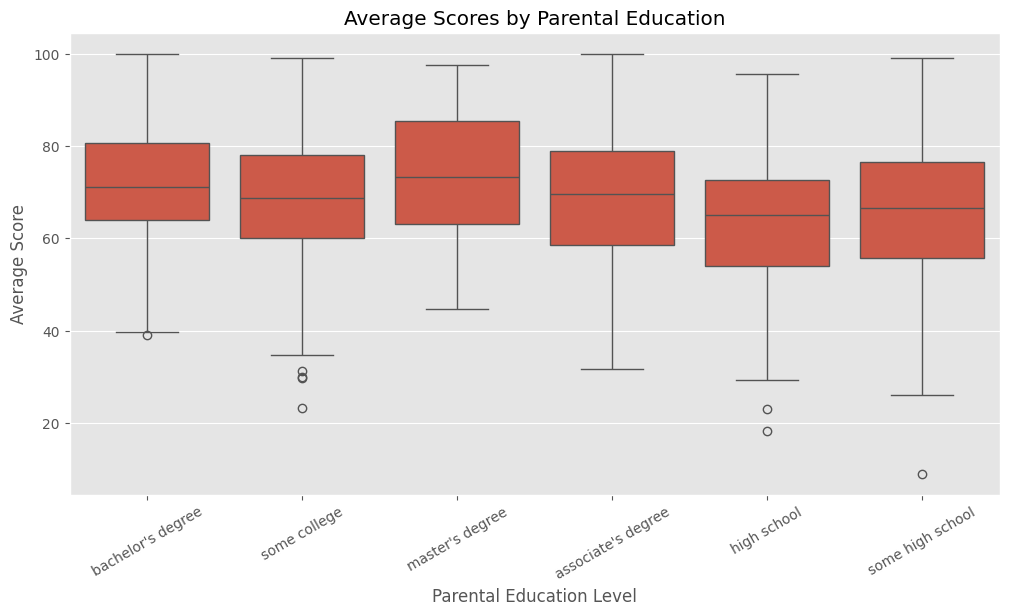

In [78]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="parental level of education",
    y="Average Score",
    data=df
)

plt.title("Average Scores by Parental Education")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")

plt.xticks(rotation=30)

plt.show()

# Chart 2: Bar Chart (Test Preparation Comparison)

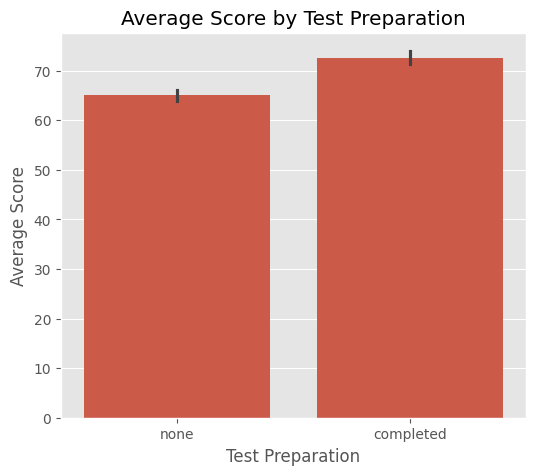

In [79]:
plt.figure(figsize=(6,5))

sns.barplot(
    x="test preparation course",
    y="Average Score",
    data=df
)

plt.title("Average Score by Test Preparation")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")

plt.show()

# Chart 3: Correlation Heatmap

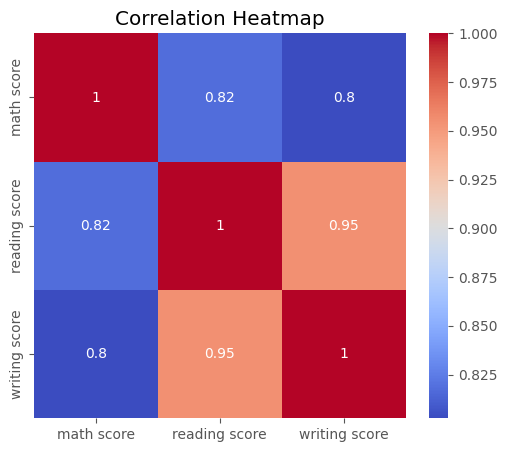

In [80]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Chart 4: Grouped Bar Chart (Gender vs Subject)

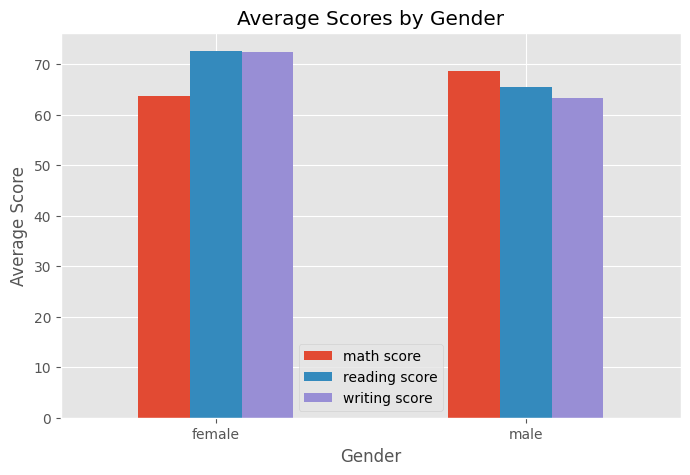

In [81]:
gender_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.show()

# Chart 5: Histogram (Total Score Distribution)

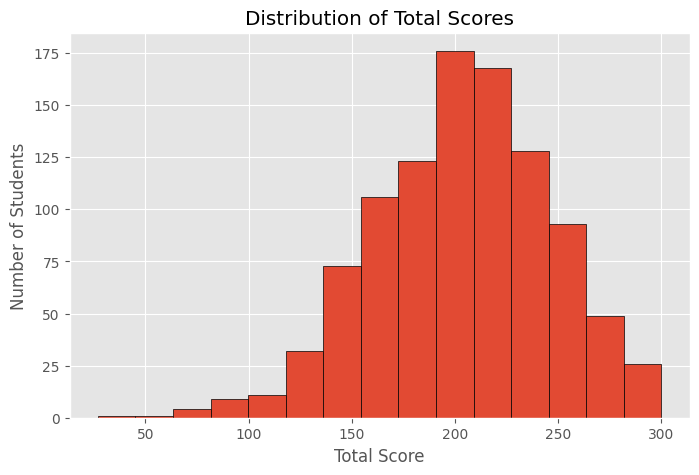

In [82]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Total Score"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

# Chart 6: Scatter Plot (Reading vs Math)

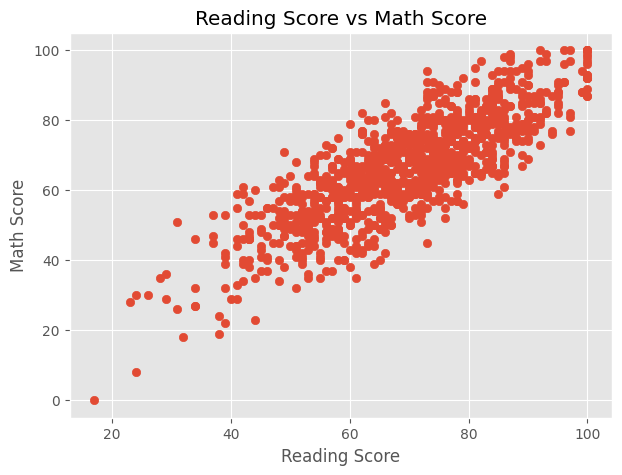

In [83]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["reading score"],
    df["math score"]
)

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.show()

# **Step 5 At-Risk Student Segmentation**

# 5.1 Create the At-Risk Student Dataset

In [84]:
# Define At-Risk
#Student scoring below 50 in any subject.

at_risk = df[
    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50)
]

# 5.2 Display the At-Risk Students

In [85]:
# head() shows the first 5 at-risk students.

at_risk.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average Score,Total Score
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,148
7,male,group B,some college,free/reduced,none,40,43,39,40.666667,122
9,female,group B,high school,free/reduced,none,38,60,50,49.333333,148
11,male,group D,associate's degree,standard,none,40,52,43,45.000000,135
17,female,group B,some high school,free/reduced,none,18,32,28,26.000000,78


# 5.3 Count the Number of At-Risk Students

In [86]:
# Count

len(at_risk)

188

# 5.4 Count the Total Number of Students

In [87]:
len(df)

1000

# 5.5 Calculate the At-Risk Percentage

In [88]:
# Percentage

#(len(at_risk)/len(df))*100

at_risk_percentage = (len(at_risk) / len(df)) * 100

print(at_risk_percentage)


18.8


# 5.6 Find At-Risk Students by Gender

In [89]:
# Group Analysis
# Example 1

# at_risk.groupby("gender").size()

gender_risk = at_risk.groupby("gender").size()

gender_risk

,0
gender,
female,89
male,99


# Find At-Risk Students by Parental Education

In [90]:
# Example 2

# at_risk.groupby("parental level of education").size()

education_risk = at_risk.groupby("parental level of education").size()

education_risk

,0
parental level of education,
associate's degree,33
bachelor's degree,16
high school,49
master's degree,6
some college,38
some high school,46


# Find At-Risk Students by Lunch Type

In [91]:
lunch_risk = at_risk.groupby("lunch").size()

lunch_risk

,0
lunch,
free/reduced,111
standard,77


# Create the At-Risk Segmentation Table

In [92]:
risk_table = at_risk.groupby(
    [
        "gender",
        "parental level of education"
    ]
).size().reset_index(name="At-Risk Students")

risk_table

,gender,parental level of education,At-Risk Students
0,female,associate's degree,15
1,female,bachelor's degree,8
2,female,high school,21
3,female,master's degree,4
4,female,some college,14
5,female,some high school,27
6,male,associate's degree,18
7,male,bachelor's degree,8
8,male,high school,28
9,male,master's degree,2


# 5.7 Explain the Results

Example 1

Students with parents who have lower education levels show a higher number of at-risk cases. This may be because these students receive less academic guidance at home.

Example 2

Students who did not complete the test preparation course appear more often in the at-risk group. Additional preparation classes could improve their performance.

# **Step 6 Principal's Report**

# Executive Summary

1. This report analyzes student performance using exam scores and demographic information.
2. The objective of the analysis was to identify the factors that influence academic performance and to identify students who may be academically at risk.
3. The findings provide useful insights that can help the school improve student performance through targeted academic support and better learning strategies.

# Key Findings

1. Students whose parents have higher education levels generally achieved better average scores.
2. Students who completed the test preparation course scored higher than those who did not complete it.
3. Reading and writing scores showed a strong positive correlation, indicating that students who performed well in one subject also tended to perform well in the other.
4. Performance differed by gender across subjects, with one gender performing better in certain subjects than the other.
5. A noticeable number of students scored below 50 in at least one subject and were identified as academically at risk.

# Recommendations

1. Encourage all students to participate in test preparation programs to improve academic performance.
2. Provide additional coaching, mentoring, and regular progress monitoring for students identified as academically at risk.
3. Increase parent involvement through regular parent-teacher meetings and awareness programs to support students' learning at home.